In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, SparsePCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
#加载数据集
data = datasets.load_breast_cancer()

X = data.data
y = data.target
feature_names = data.feature_names

print("Dataset shape:", X.shape)

Dataset shape: (569, 30)


In [ ]:
#标准化
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [ ]:
#经典PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print("PCA explained variance:", pca.explained_variance_ratio_)

PCA explained variance: [0.44272026 0.18971182]


In [ ]:
#稀疏PCA
spca = SparsePCA(n_components=2, random_state=42)
X_spca = spca.fit_transform(X_std)

In [13]:
#分类评价
def evaluate(X_embedded, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X_embedded, y, test_size=0.3, random_state=42
    )
    
    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(name, "Accuracy:", round(acc, 4))
    return acc
acc_pca = evaluate(X_pca, y, "PCA")
acc_spca = evaluate(X_spca, y, "Sparse PCA")

PCA Accuracy: 0.9708
Sparse PCA Accuracy: 0.9649


In [ ]:
#可视化
def plot_2d(X_embedded, y, title):
    plt.figure(figsize=(6,5))
    plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y,
        cmap="coolwarm",
        alpha=0.7
    )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid()
    plt.show()

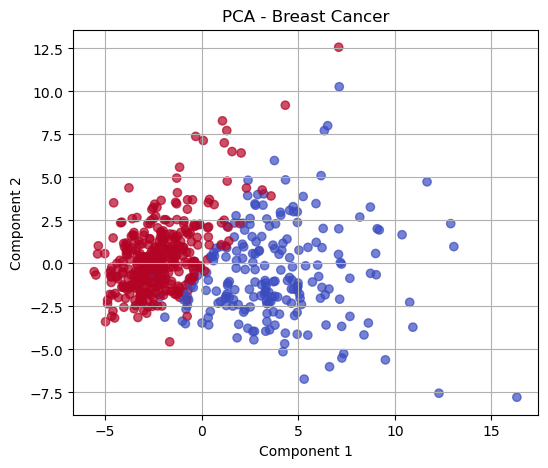

In [ ]:
plot_2d(X_pca, y, "PCA - Breast Cancer")#经典PCA

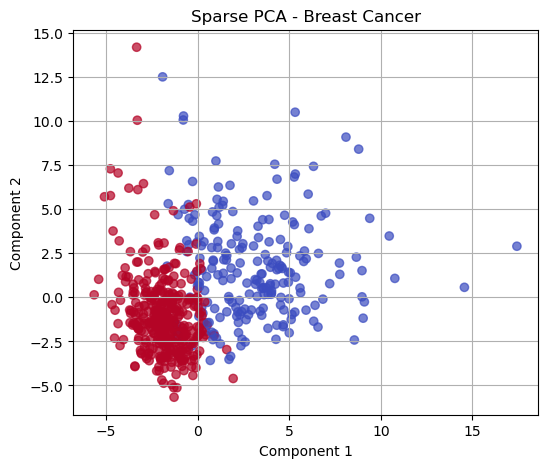

In [ ]:
plot_2d(X_spca, y, "Sparse PCA - Breast Cancer")#SPCA

In [ ]:
sparsity = np.mean(spca.components_ == 0)#稀疏指标

print("Sparse PCA sparsity (zero ratio):", round(sparsity, 4))

Sparse PCA sparsity (zero ratio): 0.15


In [12]:
print("\n===== Final Comparison =====")
print("PCA Accuracy:", round(acc_pca, 4))
print("Sparse PCA Accuracy:", round(acc_spca, 4))
print("Sparse PCA Sparsity:", round(sparsity, 4))


===== Final Comparison =====
PCA Accuracy: 0.9708
Sparse PCA Accuracy: 0.9649
Sparse PCA Sparsity: 0.15
